In [2]:
import os
import pandas as pd
import numpy as np

# パスを正しく展開
file_path = os.path.expanduser('~/Documents/soturon/HR/Time_Series_20080105_1228_corrected.d')

# テキストファイルをスペース区切りとしてDataFrameに変換
df = pd.read_csv(file_path, delimiter=r'\s+', header=None)

# 1列目に-1が出るまでを1つのレースとしてデータを分割
race_indices = df[df[0] == -1].index

raceごとに分解

In [3]:
races_list = []

start_idx = 0
for i, idx in enumerate(race_indices):
    race_df = df.iloc[start_idx:idx]
    races_list.append(race_df)
    start_idx = idx + 1

総投票数を取得

In [4]:
total_votes = []

for i , race_df in enumerate(races_list):
    num_votes = race_df.iloc[1:,1].to_numpy()
    total_votes.append(num_votes)

print(total_votes[3].shape)

(44,)


オッズと得票率をを取得

In [5]:
vote_list = []
odds_list = []

for i, race_df in enumerate(races_list):
    # オッズの計算
    odds_df = race_df.iloc[1:,2:]
    odds_df = odds_df.loc[:, (odds_df != 0).any(axis=0)]# odds_dfの内、列が全て０の列を削除
    odds_list.append(odds_df)

    # 得票率の計算
    vote_df = 0.8 / odds_df.replace(0, float('inf')) #オッズの逆数を取り、0の場合はinfに置き換えてから0.8を掛ける
    vote_df[odds_df == 0] = 0
    vote_df = vote_df.loc[:, (vote_df != 0).any(axis=0)]# vote_dfの内、列が全て０の列を削除
    vote_list.append(vote_df)

In [6]:
# 各行の0以外の最小値に0.05を加える処理
def add_to_minimum(row):
    # 0以外の要素をフィルタリング
    non_zero_values = row[row != 0]

    # 0以外の最小値が存在する場合のみ処理
    if not non_zero_values.empty:
        # 0以外の最小値を取得
        min_index = non_zero_values.idxmin()  # 最小値のインデックス
        row[min_index] += 0.05  # 0.05を加算
    return row

# データフレームに処理を適用
odds_df = odds_df.apply(add_to_minimum, axis=1)

オッズ補正

In [7]:
correct_odds_list = []
correct_vote_list = []

for j, race_df in enumerate(races_list):
    # オッズの計算
    odds_df = race_df.iloc[1:,2:]
    odds_df = odds_df.loc[:, (odds_df != 0).any(axis=0)]# odds_dfの内、列が全て０の列を削除
    odds_df = odds_df.apply(add_to_minimum, axis=1)
    correct_odds_list.append(odds_df)

    # 得票率の計算
    vote_df = 0.8 / odds_df.replace(0, float('inf')) #オッズの逆数を取り、0の場合はinfに置き換えてから0.8を掛ける
    vote_df[odds_df == 0] = 0
    vote_df = vote_df.loc[:, (vote_df != 0).any(axis=0)]# vote_dfの内、列が全て０の列を削除
    correct_vote_list.append(vote_df)

In [8]:
vote_list = [np.array(vote_df) for vote_df in correct_vote_list]
print(vote_list[3].shape)

(44, 14)


1%ごとに線形補間

In [9]:
import numpy as np
np.set_printoptions(suppress=True)

for i, total in enumerate(total_votes):
    total = (total.astype(float) / total[-1].astype(float) * 100.0).round(3)
    total_votes[i] = total

print(total_votes[9])
print(vote_list[9])

[  0.003   0.056   0.177   0.326   0.398   0.463   0.583   0.704   0.785
   1.113   1.304   1.386   1.55    1.663   1.802   2.033   2.078   2.172
   2.31    2.451   2.759   3.065   3.334   3.703   4.022   4.412   4.692
   5.203   5.414   5.704   5.984   6.224   6.53    6.668   7.016   7.434
   7.831   8.179   8.568   8.876   9.225   9.525   9.859  10.242  10.679
  11.084  11.695  12.158  12.682  13.172  13.593  14.095  14.614  15.007
  15.574  16.125  16.495  17.143  18.359  19.621  20.444  21.767  27.689
  38.998  51.582  74.034 100.    100.   ]
[[0.         0.         0.15384615 0.         0.         0.
  0.         0.69565217 0.         0.         0.         0.
  0.0776699  0.        ]
 [0.01441441 0.00961538 0.0952381  0.125      0.03361345 0.02877698
  0.14285714 0.21333333 0.07207207 0.01441441 0.03846154 0.05263158
  0.01441441 0.14814815]
 [0.00918485 0.0076555  0.1        0.11940299 0.11111111 0.02139037
  0.14814815 0.11428571 0.20253165 0.0076555  0.02749141 0.03053435
  0.0

In [10]:
from scipy.interpolate import interp1d

linear_vote_list = []

for i in range(len(total_votes)):
    f = interp1d(total_votes[i], vote_list[i], axis=0, kind='linear')
    interpolated_values = f(np.arange(1,101))
    linear_vote_list.append(interpolated_values)

見てみる

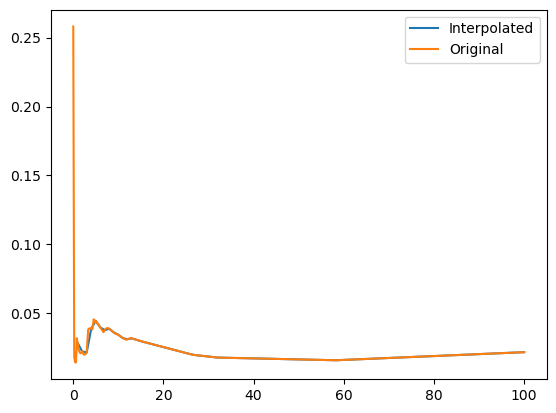

In [11]:
from matplotlib import pyplot as plt


plt.plot(np.arange(1,101), linear_vote_list[0][:,0], label='Interpolated')
plt.plot(total_votes[0], vote_list[0][:,0], label='Original')
plt.legend()
plt.show()

In [12]:
import pandas as pd

# 横方向に結合
combined_vote_df = pd.concat([pd.DataFrame(data) for data in linear_vote_list], axis=1)

# 結合されたDataFrameを表示
print(combined_vote_df.shape)

(100, 50320)


データ完成

In [13]:
print(combined_vote_df)
vote_array = np.array(combined_vote_df)

          0         1         2         3         4         5         6   \
0   0.028409  0.143673  0.007851  0.019024  0.144975  0.097019  0.041035   
1   0.022339  0.151615  0.013232  0.025598  0.155252  0.085380  0.038128   
2   0.021801  0.155104  0.012395  0.024350  0.130978  0.095238  0.041475   
3   0.038912  0.140024  0.014746  0.031868  0.127102  0.095650  0.050010   
4   0.044599  0.129032  0.015450  0.044398  0.117484  0.088704  0.058236   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.021296  0.214193  0.007657  0.016334  0.225978  0.073460  0.044697   
96  0.021437  0.214699  0.007616  0.016283  0.225822  0.073443  0.044887   
97  0.021577  0.215205  0.007574  0.016231  0.225665  0.073427  0.045076   
98  0.021717  0.215711  0.007532  0.016180  0.225509  0.073411  0.045265   
99  0.021858  0.216216  0.007491  0.016129  0.225352  0.073394  0.045455   

          7         8         9   ...        6         7         8         9   \
0   0.

In [14]:
import numpy as np

# 各列の最後の行（21行目）の値を取得
last_row_values = vote_array[-1, :]  # -1で最後の行を取得

# 各列を最後の行の値でソートするためのインデックスを取得
sorted_indices = np.argsort(last_row_values)

# 列をソート
sorted_vote_array = vote_array[:, sorted_indices]

# ソート後に各列の100行目の値を取得
row_100_values = sorted_vote_array[99, :]

print(sum(row_100_values < 0))

9


In [15]:
# row_100_values が 0 の列を除外
non_zero_indices = np.where(row_100_values > 0.0)[0]  # 0以外の列インデックスを取得
filtered_vote_array = sorted_vote_array[:, non_zero_indices]
filtered_row_100_values = row_100_values[non_zero_indices]
print(sum(filtered_row_100_values <= 0.0))

difference_array = filtered_vote_array - filtered_row_100_values  

0


差と最終得票率の配列作成

In [16]:
# filtered_row_21_values を2次元配列に変換
filtered_row_100_values_2d = filtered_row_100_values[np.newaxis, :]

# result_array と filtered_row_21_values を結合
final_array = np.vstack((difference_array, filtered_row_100_values_2d))

print(final_array.shape)
print(final_array[:,0])

(101, 50184)
[0.01912412 0.03448495 0.02848451 0.03075445 0.02606739 0.02232814
 0.0203955  0.01838161 0.01696688 0.01616136 0.01535584 0.01455032
 0.01388968 0.01345472 0.01301976 0.0125848  0.01214983 0.01171487
 0.01127991 0.01084495 0.01040999 0.00997502 0.00954006 0.0091051
 0.00867014 0.00823517 0.00780021 0.00760343 0.00759315 0.00758288
 0.0075726  0.00756232 0.00755204 0.00754177 0.00753149 0.00752121
 0.00751093 0.00750066 0.00748757 0.00736482 0.00724207 0.00711933
 0.00699658 0.00687383 0.00675109 0.00662834 0.00650559 0.00638284
 0.0062601  0.00613735 0.0060146  0.00589186 0.00576911 0.00564636
 0.00552362 0.00540087 0.00527812 0.00515537 0.00503263 0.00490988
 0.00478713 0.00466439 0.00454164 0.00441889 0.00429615 0.0041734
 0.00405065 0.0039279  0.00380516 0.00368241 0.00355966 0.00343692
 0.00331417 0.00319142 0.00306868 0.00294593 0.00282318 0.00270043
 0.00257769 0.00245494 0.00233219 0.00220945 0.0020867  0.00196395
 0.00184121 0.00171846 0.00159571 0.00147296 0.0013

各最終得票率での得票率の変化の配列作成

In [17]:
split_list = []

for lower_bound in np.arange(0, 0.7, 0.01):
    upper_bound = lower_bound + 0.01

    mask = (final_array[-1,:] >= lower_bound) & (final_array[-1,:] < upper_bound)
    selected_array = final_array[:, mask]
    split_list.append(selected_array)

qごとにx-qの二乗平均のダイナミクスを調べる

In [18]:
from numpy import mean

square_x_q = np.square(split_list[0][0:100,:])
mean_square_x_q = mean(square_x_q, axis=1)

print(mean_square_x_q.shape)

(100,)


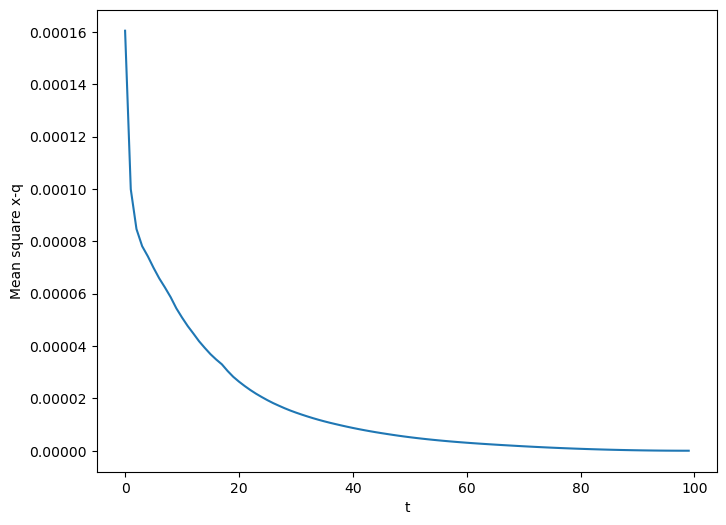

In [19]:
plt.figure(figsize=(8, 6))
t = np.arange(0, 100)
plt.plot(t, mean_square_x_q)
plt.xlabel("t")
plt.ylabel("Mean square x-q")
plt.show()

In [20]:
mean_square_x_q_list = []

for i in range(0,70):
    square_x_q = np.square(split_list[i][0:100,:])
    mean_square_x_q = mean(square_x_q, axis=1)
    mean_square_x_q_list.append(mean_square_x_q)   

/home/mori/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mori/.local/lib/python3.10/site-packages/numpy/core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [21]:
log_mean_square_x_q_list = []

for i in range(0,70):
    log_mean_square_x_q = np.log(mean_square_x_q_list[i])
    log_mean_square_x_q_list.append(log_mean_square_x_q) 

/tmp/ipykernel_64681/1755195508.py:4: RuntimeWarning: divide by zero encountered in log
  log_mean_square_x_q = np.log(mean_square_x_q_list[i])


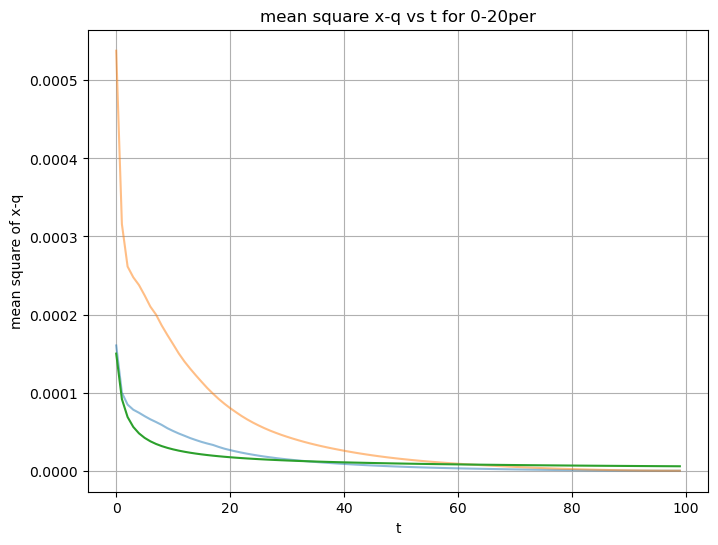

In [233]:
plt.figure(figsize=(8, 6))

t = np.arange(0, 100)

for i in range(0,2):
    y = mean_square_x_q_list[i]
    plt.plot(t,y,alpha=0.5, label=f"{i}-{i+1}per")


z = 0.00015/(t+1)**(0.71)
plt.plot(t,z,label="1/(t+1)^2")
plt.xlabel("t")
plt.ylabel("mean square of x-q")
plt.title("mean square x-q vs t for 0-20per")
plt.grid(True)
plt.show()

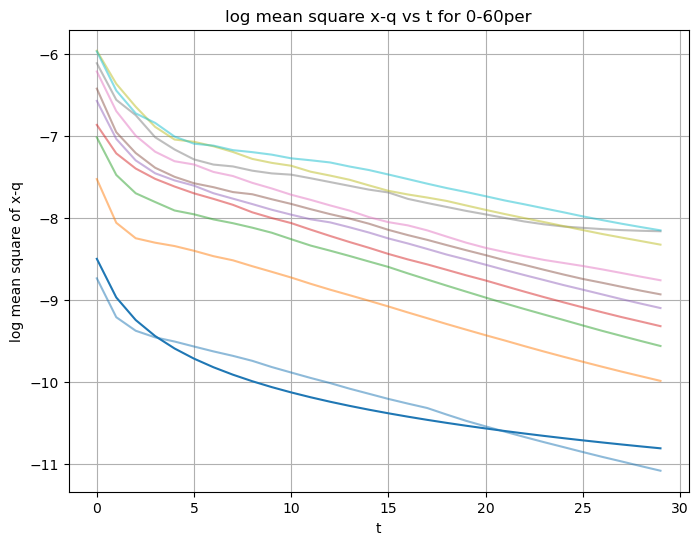

In [373]:
plt.figure(figsize=(8, 6))

t = np.arange(0, 30)

for i in range(0,10):
    y = log_mean_square_x_q_list[i][0:30]
    plt.plot(t,y,alpha=0.5, label=f"{i}-{i+1}per")


z = -(alpha_est_list[0]*np.log(t+1))-8.5
plt.plot(t,z)

plt.xlabel("t")
plt.ylabel("log mean square of x-q")
plt.title("log mean square x-q vs t for 0-60per")
plt.grid(True)
#plt.legend()
plt.show()

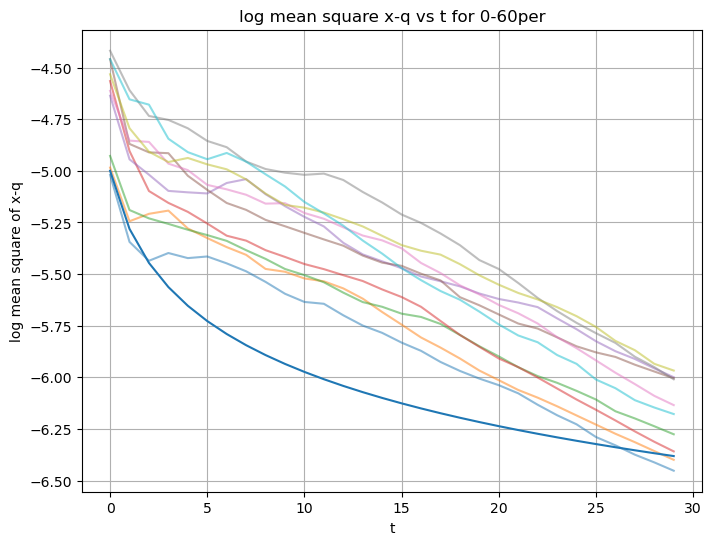

In [372]:
plt.figure(figsize=(8, 6))

t = np.arange(0, 30)

for i in range(20,30):
    y = log_mean_square_x_q_list[i][0:30]
    plt.plot(t,y,alpha=0.5, label=f"{i}-{i+1}per")


z = -(alpha_est_list[20]*np.log(t+1))-5
plt.plot(t,z)

plt.xlabel("t")
plt.ylabel("log mean square of x-q")
plt.title("log mean square x-q vs t for 0-60per")
plt.grid(True)
#plt.legend()
plt.show()


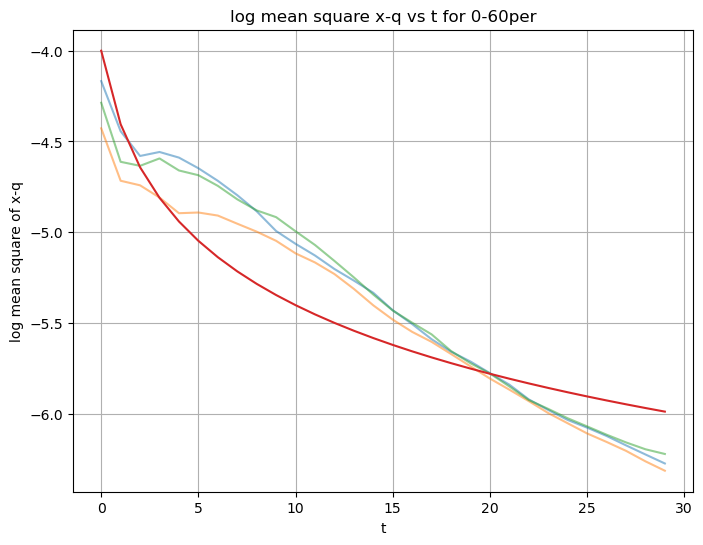

In [386]:
plt.figure(figsize=(8, 6))

t = np.arange(0, 30)

for i in range(30,33):
    y = log_mean_square_x_q_list[i][0:30]
    plt.plot(t,y,alpha=0.5, label=f"{i}-{i+1}per")


z = -(alpha_est_list[31]*np.log(t+1))-4
plt.plot(t,z)

plt.xlabel("t")
plt.ylabel("log mean square of x-q")
plt.title("log mean square x-q vs t for 0-60per")
plt.grid(True)
#plt.legend()
plt.show()

In [278]:
import numpy as np

nan_indices = [i for i, y in enumerate(log_mean_square_x_q_list) if np.isnan(y).any()]
print(nan_indices)


[38, 40, 42, 44, 46, 47, 49, 50, 52, 53, 54, 56, 57, 58, 60, 61, 62, 63, 65, 66, 67, 68]


alphaの推定

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


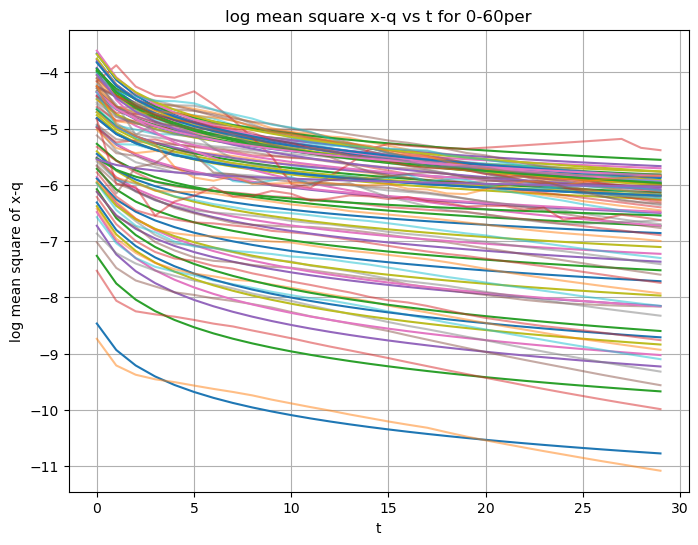

In [292]:
from math import nan
from scipy.optimize import curve_fit

plt.figure(figsize=(8, 6))

# 定義する関数
def model_func(t, alpha, beta):
    return -(alpha * np.log(t + 1)) - beta

# 初期推定値
initial_guess = [0.37, 5.5]

t = np.arange(0, 30)
alpha_est_list = []

for i in range(0,70):
    print(i)
    y = log_mean_square_x_q_list[i][0:30]
    if i in nan_indices:
        alpha_est_list.append(0)
        continue
    params, params_covariance = curve_fit(model_func, t, y, p0=initial_guess)
    alpha_est, beta_est = params
    alpha_est_list.append(alpha_est)
    z_est = model_func(t, alpha_est, beta_est)
    plt.plot(t, z_est, label=f"Fitted: alpha={alpha_est:.2f}, beta={beta_est:.2f}")
    plt.plot(t,y,alpha=0.5, label=f"{i}-{i+1}per")


plt.xlabel("t")
plt.ylabel("log mean square of x-q")
plt.title("log mean square x-q vs t for 0-60per")
plt.grid(True)
#plt.legend()
plt.show()


[0.6792086874516956, 0.7085312796957453, 0.7358282124462516, 0.7477298273049621, 0.7231302262429485, 0.7051258019567428, 0.7413725109966057, 0.5959289669627493, 0.6763955748391304, 0.5893426286630431, 0.5364619758847281, 0.5305472626956818, 0.545059700105599, 0.5032180853628547, 0.5005821855333995, 0.413944238216071, 0.4283819518397353, 0.44837917894099144, 0.4447328087462416, 0.44022744598524516, 0.406190025774594, 0.4349342194230264, 0.39276970674127776, 0.4943843577303615, 0.37689093850051336, 0.437885724549027, 0.43762391414936314, 0.4598666310017627, 0.40050715359451156, 0.5458208974654378, 0.6800635489760336, 0.5845139049296091, 0.6363055961792241, 0.8260817112015298, 0.6615572637689274, 0.5737371935897667, 0.46689396260355315, 0.6025402630849184, 0, 0.682865175019294, 0, 0.6123252113678092, 0, 0.5966100465611152, 0, 0.5949166958219453, 0, 0, 0.5980571212275978, 0, 0, 0.43904456187599716, 0, 0, 0, 0.43340682985514595, 0, 0, 0, 0.4039491041596673, 0, 0, 0, 0, 0.2990146041974587, 0

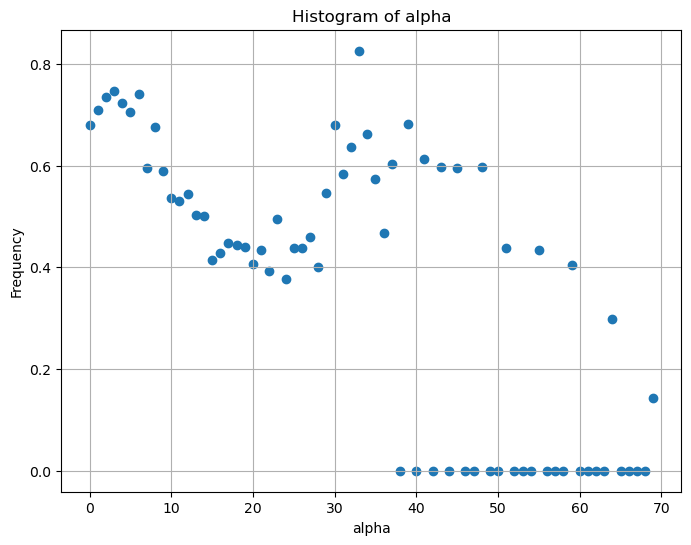

In [293]:
print(alpha_est_list)
s = np.arange(len(alpha_est_list))
plt.figure(figsize=(8, 6))
plt.scatter(s,alpha_est_list)
plt.xlabel("alpha")
plt.ylabel("Frequency")
plt.title("Histogram of alpha")
plt.grid(True)
plt.show()

$ a(t,q) = \frac{\alpha(q)}{2(t+1)}$

In [306]:
a_list = []

t = np.arange(0, 100)
for i in range(0, 70):
    if alpha_est_list[i] != 0:
        a_list.append(alpha_est_list[i] /( 2 * (t + 1)))
    else:
        a_list.append(np.zeros(100))

a_list = np.array(a_list)
print(a_list.shape)
print(a_list[0])

(70, 100)
[0.33960434 0.16980217 0.11320145 0.08490109 0.06792087 0.05660072
 0.04851491 0.04245054 0.03773382 0.03396043 0.03087312 0.02830036
 0.02612341 0.02425745 0.02264029 0.02122527 0.01997673 0.01886691
 0.01787391 0.01698022 0.01617164 0.01543656 0.01476541 0.01415018
 0.01358417 0.01306171 0.01257794 0.01212873 0.01171049 0.01132014
 0.01095498 0.01061264 0.01029104 0.00998836 0.00970298 0.00943345
 0.0091785  0.00893696 0.0087078  0.00849011 0.00828303 0.00808582
 0.00789778 0.00771828 0.00754676 0.0073827  0.00722562 0.00707509
 0.0069307  0.00679209 0.00665891 0.00653085 0.00640763 0.00628897
 0.00617462 0.00606436 0.00595797 0.00585525 0.00575601 0.00566007
 0.00556728 0.00547749 0.00539055 0.00530632 0.00522468 0.00514552
 0.00506872 0.00499418 0.0049218  0.00485149 0.00478316 0.00471673
 0.00465211 0.00458925 0.00452806 0.00446848 0.00441045 0.0043539
 0.00429879 0.00424505 0.00419265 0.00414152 0.00409162 0.00404291
 0.00399535 0.00394889 0.0039035  0.00385914 0.003815

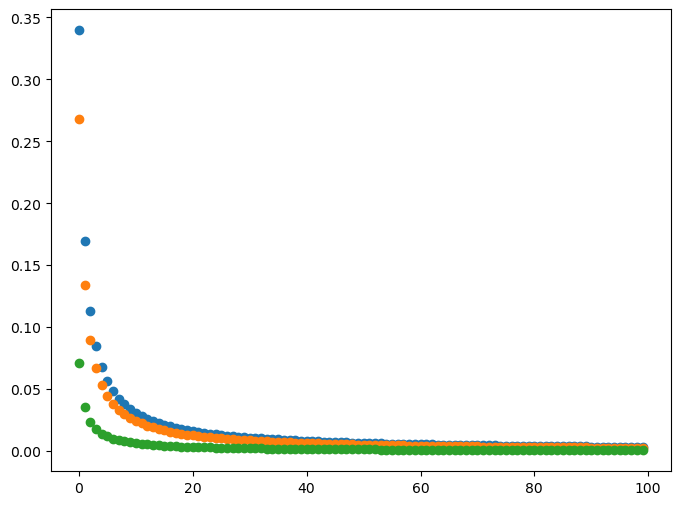

In [330]:
plt.figure(figsize=(8, 6))

plt.scatter(t, a_list[0], label='alpha') 
plt.scatter(t, a_list[10], label='alpha') 
#plt.scatter(t, a_list[30], label='alpha', alpha=0.5)
plt.scatter(t, a_list[69], label='alpha') 

あってんのか？

時間相関

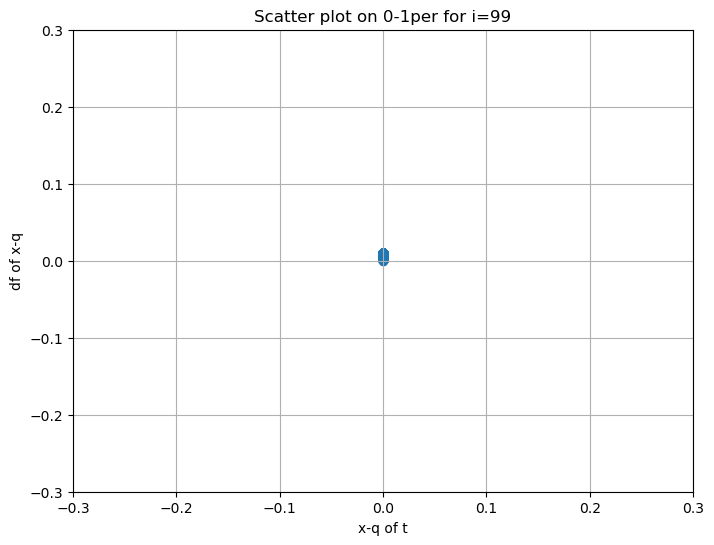

In [191]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[0][i, :]
    y = split_list[0][i + 1, :]-x
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 0-1per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_0-1.gif", writer="pillow")
plt.show()

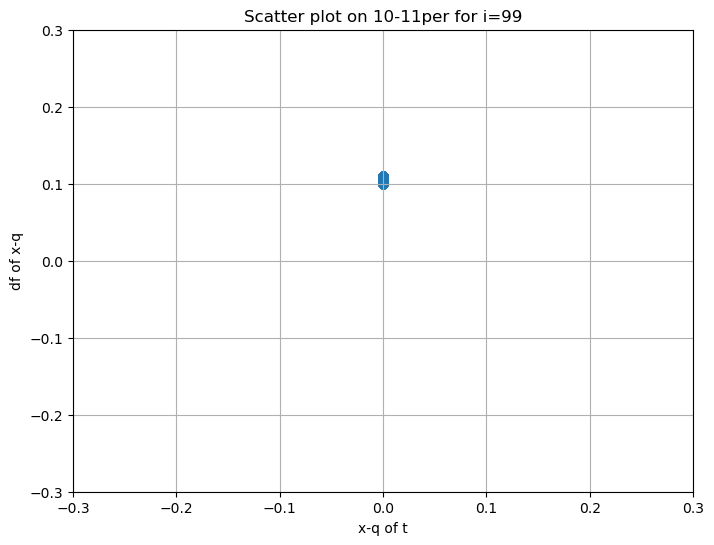

In [192]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[10][i, :]
    y = split_list[10][i + 1, :]-x
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 10-11per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_10-11.gif", writer="pillow")
plt.show()

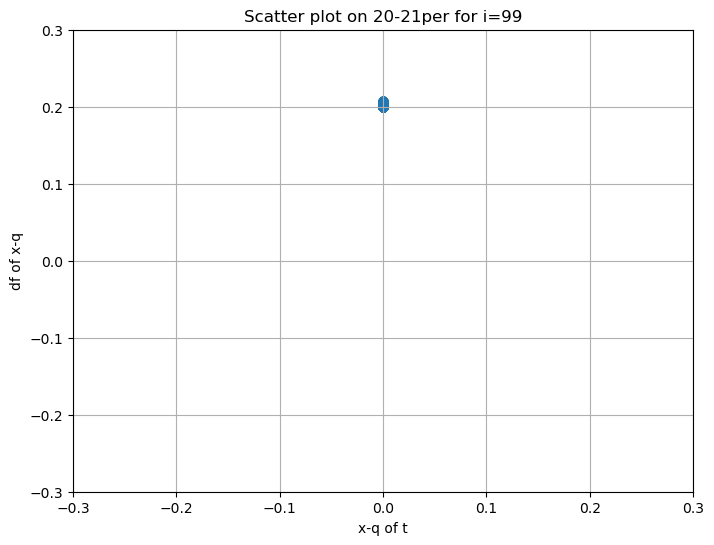

In [193]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[20][i, :]
    y = split_list[20][i + 1, :]-x
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 20-21per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_20-21.gif", writer="pillow")
plt.show()

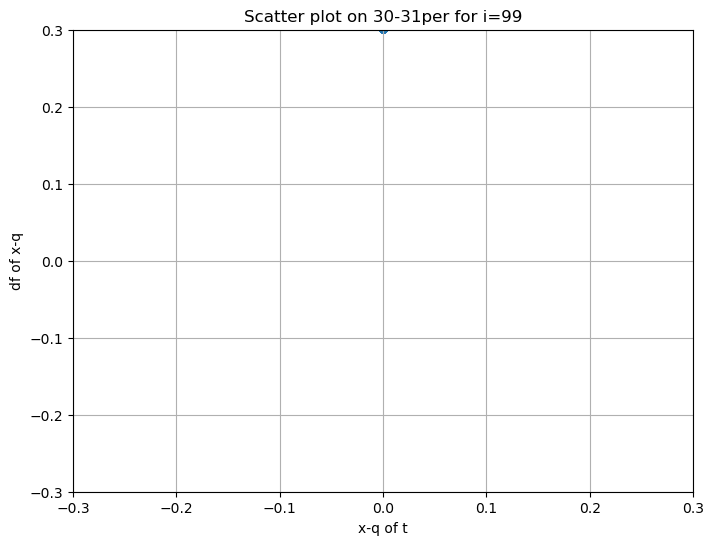

In [194]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[30][i, :]
    y = split_list[30][i + 1, :]-x
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 30-31per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_30-31.gif", writer="pillow")
plt.show()

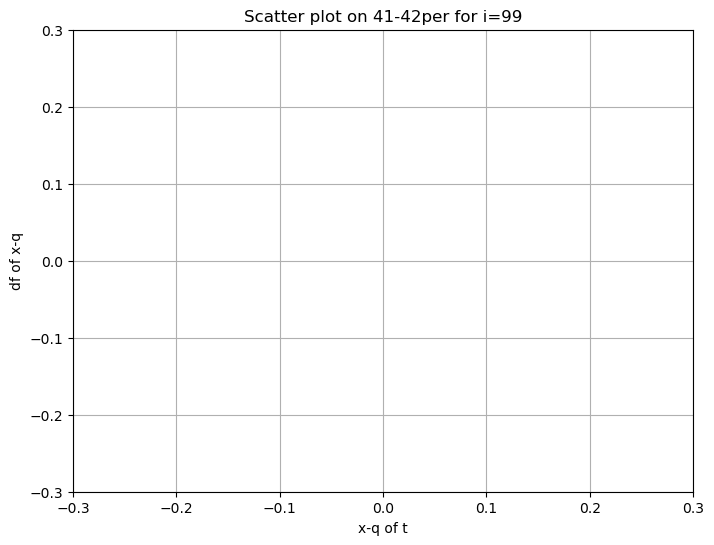

In [195]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[41][i, :]
    y = split_list[41][i + 1, :]-x
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 41-42per for i={i}")

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_41-42.gif", writer="pillow")
plt.show()

ValueError: Cannot calculate a linear regression if all x values are identical

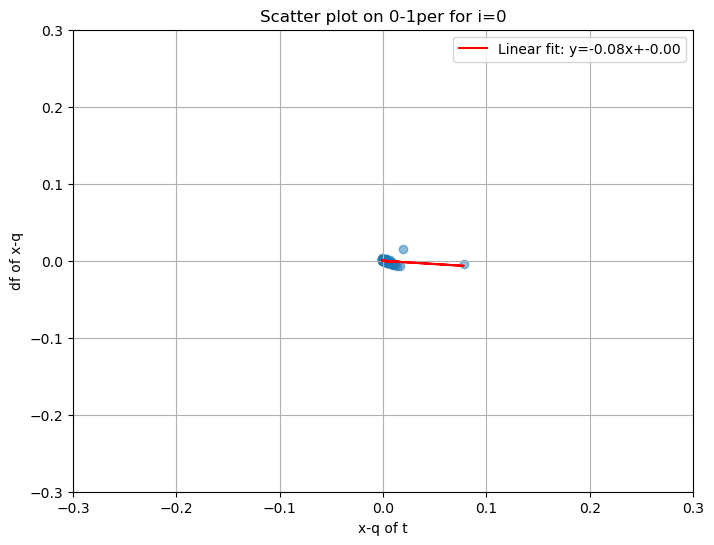

In [186]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[0][i, :100]
    y = split_list[0][i + 1, :100] - x
    ax.scatter(x, y, alpha=0.5)
    
    # 線形回帰
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line = slope * x + intercept
    ax.plot(x, line, color='red', label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}')
    
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 0-1per for i={i}")
    ax.legend()

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_0-1_with_regression.gif", writer="pillow")
plt.show()

ValueError: Cannot calculate a linear regression if all x values are identical

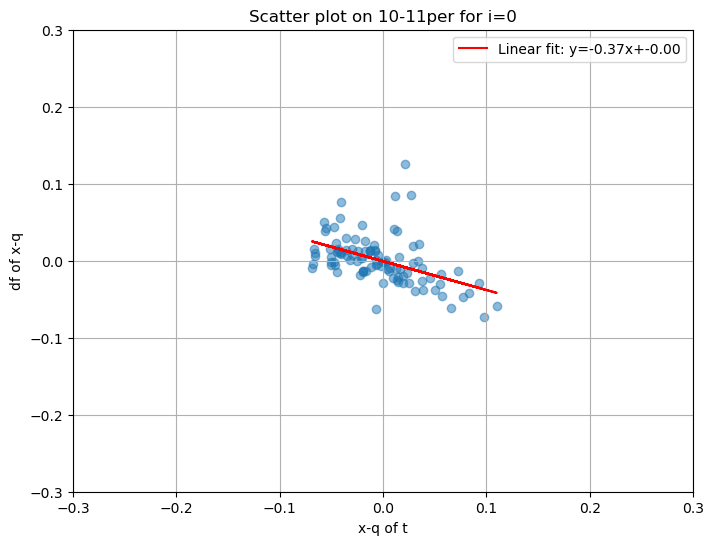

In [187]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[10][i, :100]
    y = split_list[10][i + 1, :100] - x
    ax.scatter(x, y, alpha=0.5)
    
    # 線形回帰
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line = slope * x + intercept
    ax.plot(x, line, color='red', label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}')
    
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 10-11per for i={i}")
    ax.legend()

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_10-11_with_regression.gif", writer="pillow")
plt.show()

ValueError: Cannot calculate a linear regression if all x values are identical

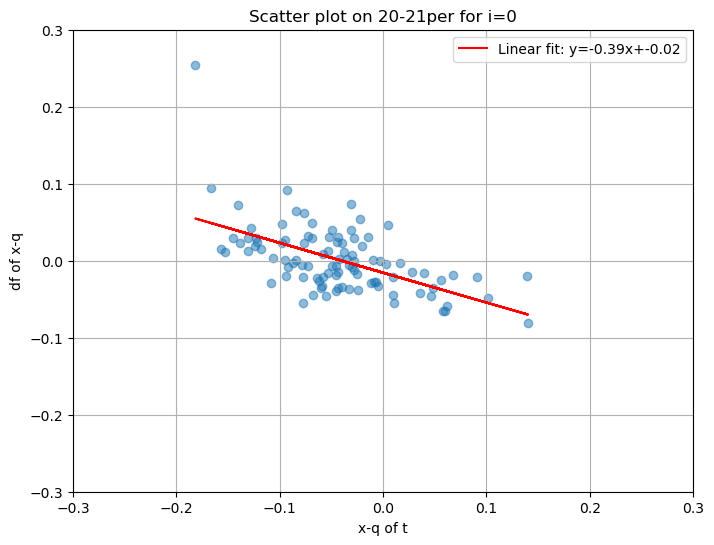

In [ ]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[20][i, :]
    y = split_list[20][i + 1, :] - x
    ax.scatter(x, y, alpha=0.5)
    
    # 線形回帰
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line = slope * x + intercept
    ax.plot(x, line, color='red', label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}')
    
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 20-21per for i={i}")
    ax.legend()

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_20-21_with_regression.gif", writer="pillow")
plt.show()

KeyboardInterrupt: 

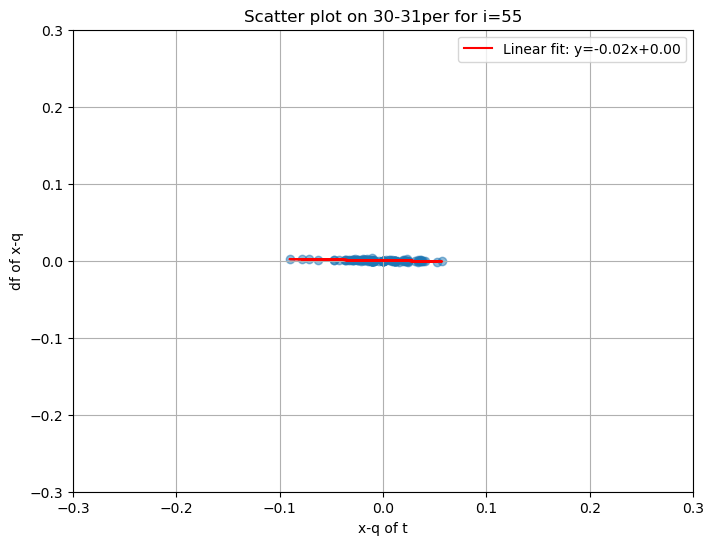

In [189]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[30][i, :99]
    y = split_list[30][i + 1, :99] - x
    ax.scatter(x, y, alpha=0.5)
    
    # 線形回帰
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line = slope * x + intercept
    ax.plot(x, line, color='red', label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}')
    
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 30-31per for i={i}")
    ax.legend()

ani = animation.FuncAnimation(fig, update, frames=range(0, 99), repeat=False)
ani.save("df of x-q plot_30-31_with_regression.gif", writer="pillow")
plt.show()

ValueError: Cannot calculate a linear regression if all x values are identical

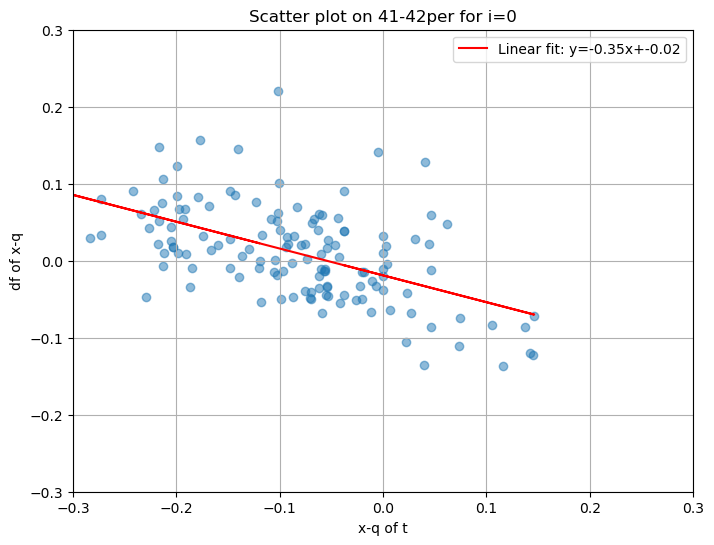

In [197]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[41][i, :]
    y = split_list[41][i + 1, :] - x
    ax.scatter(x, y, alpha=0.5)
    
    # 線形回帰
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line = slope * x + intercept
    ax.plot(x, line, color='red', label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}')
    
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 41-42per for i={i}")
    ax.legend()

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_41-42_with_regression.gif", writer="pillow")
plt.show()

ValueError: Cannot calculate a linear regression if all x values are identical

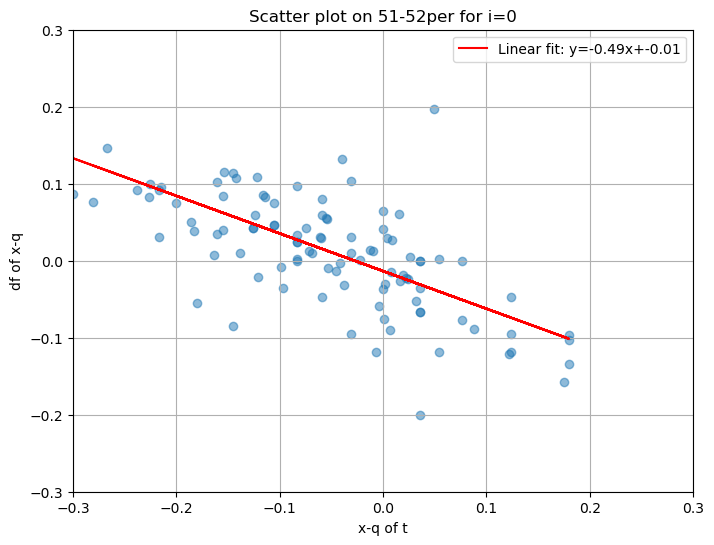

In [196]:
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(8, 6))

def update(i):
    ax.clear()
    x = split_list[51][i, :]
    y = split_list[51][i + 1, :] - x
    ax.scatter(x, y, alpha=0.5)
    
    # 線形回帰
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line = slope * x + intercept
    ax.plot(x, line, color='red', label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}')
    
    ax.set_xlabel("x-q of t")
    ax.set_ylabel("df of x-q")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    ax.grid(True)
    ax.set_title(f"Scatter plot on 51-52per for i={i}")
    ax.legend()

ani = animation.FuncAnimation(fig, update, frames=range(0, 100), repeat=False)
ani.save("df of x-q plot_51-52_with_regression.gif", writer="pillow")
plt.show()

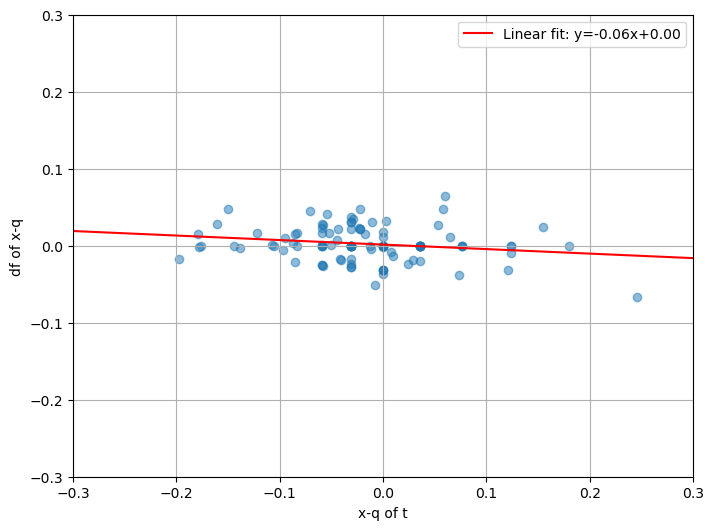

In [354]:
plt.figure(figsize=(8, 6))
i = 4
x = split_list[51][i, :]
y = split_list[51][i+1, :] - x
plt.scatter(x, y, alpha=0.5)

c = np.arange(-1,1,0.1)
# 線形回帰
slope, intercept, r_value, p_value, std_err = linregress(x, y)
line = slope * c + intercept
plt.plot(c, line, color='red', label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel("x-q of t")
plt.ylabel("df of x-q")
plt.xlim(-0.3, 0.3)
plt.ylim(-0.3, 0.3)
plt.grid(True)
plt.legend()
plt.show()
